Using device: cuda
OOD DETECTOR TRAINING

PREPARING DATASET
Loading brain MRI images...
  ✓ Loaded 11300 brain MRI images
Loading non-MRI images (CIFAR-100)...
  ✓ Loaded 60000 non-MRI images

Total samples: 71300
  Positive (MRI): 11300
  Negative (non-MRI): 60000

Train samples: 57040
Val samples: 14260

INITIALIZING MODEL


Downloading: "https://download.pytorch.org/models/mobilenet_v3_small-047dcff4.pth" to C:\Users\anish/.cache\torch\hub\checkpoints\mobilenet_v3_small-047dcff4.pth
100%|██████████| 9.83M/9.83M [00:02<00:00, 4.38MB/s]
c:\Users\anish\anaconda3\envs\gridlock\lib\site-packages\torch\optim\lr_scheduler.py:62: UserWarning: The verbose parameter is deprecated. Please use get_last_lr() to access the learning rate.
  warnings.warn(


Total parameters: 964,001
Trainable parameters: 964,001

TRAINING OOD DETECTOR



Epoch [1/15]
  Train Loss: 0.0254 | Train Acc: 99.65%
  Val Loss: 0.0002 | Val Acc: 100.00%
  ✓ Best model saved (acc: 100.00%)



Epoch [2/15]
  Train Loss: 0.0004 | Train Acc: 100.00%
  Val Loss: 0.0000 | Val Acc: 100.00%


...


Epoch [11/15]
  Train Loss: 0.0000 | Train Acc: 100.00%
  Val Loss: 0.0000 | Val Acc: 100.00%



Epoch [12/15]
  Train Loss: 0.0000 | Train Acc: 100.00%
  Val Loss: 0.0000 | Val Acc: 100.00%



Epoch [13/15]
  Train Loss: 0.0000 | Train Acc: 100.00%
  Val Loss: 0.0000 | Val Acc: 100.00%



Epoch [14/15]
  Train Loss: 0.0000 | Train Acc: 100.00%
  Val Loss: 0.0000 | Val Acc: 100.00%



Epoch [15/15]
  Train Loss: 0.0000 | Train Acc: 100.00%
  Val Loss: 0.0000 | Val Acc: 100.00%

TRAINING COMPLETE
Best validation accuracy: 100.00%
Model saved to: ../models/ood_detector.pth

✓ Training curves saved to: ../results/ood_detector_training.png


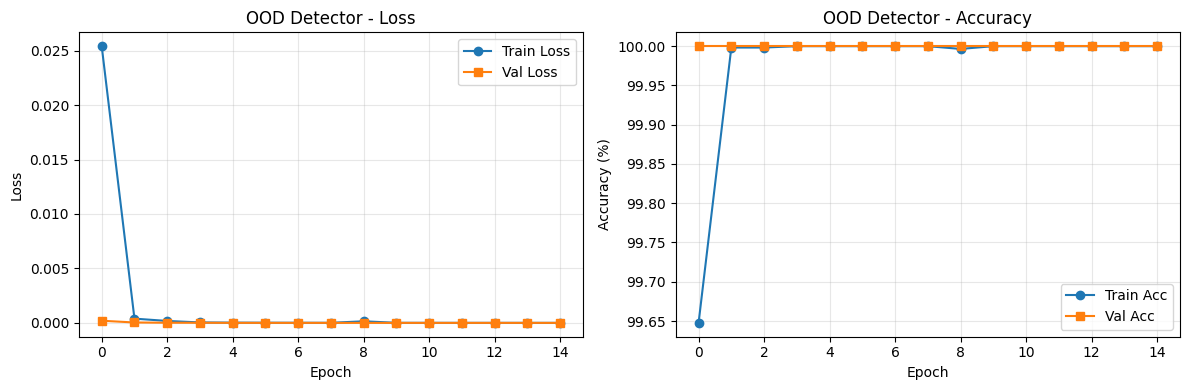


OOD Detector ready to use! ✓


In [1]:
import torch
import torch.nn as nn
from torchvision import models, transforms
from torch.utils.data import Dataset, DataLoader
from pathlib import Path
from PIL import Image
import numpy as np
from tqdm import tqdm
import matplotlib.pyplot as plt

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

# ============================================================================
# 1. OOD DETECTOR MODEL
# ============================================================================

class OODDetector(nn.Module):
    """
    Binary classifier: Is this a brain MRI or not?
    Output: 1 = brain MRI, 0 = not brain MRI
    Uses MobileNetV3-Small (fast, lightweight)
    """
    def __init__(self):
        super().__init__()
        backbone = models.mobilenet_v3_small(
            weights=models.MobileNet_V3_Small_Weights.IMAGENET1K_V1
        )
        in_features = backbone.classifier[0].in_features
        
        # Replace classifier
        backbone.classifier = nn.Sequential(
            nn.Linear(in_features, 64),
            nn.ReLU(inplace=True),
            nn.Dropout(0.3),
            nn.Linear(64, 1)  # Single output for binary classification
        )
        self.backbone = backbone
    
    def forward(self, x):
        return self.backbone(x)


# ============================================================================
# 2. DATASET
# ============================================================================

class BinaryMRIDataset(Dataset):
    """
    Loads brain MRI images (label=1) and non-MRI images (label=0)
    """
    def __init__(self, mri_dir, non_mri_dir, transform=None, max_samples=None):
        self.transform = transform
        self.samples = []
        
        # Positive samples: Brain MRI (label = 1)
        print("Loading brain MRI images...")
        mri_path = Path(mri_dir)
        mri_count = 0
        for img_path in sorted(mri_path.rglob("*.jpg")) + sorted(mri_path.rglob("*.png")):
            if max_samples and mri_count >= max_samples:
                break
            self.samples.append((str(img_path), 1.0))
            mri_count += 1
        
        print(f"  ✓ Loaded {mri_count} brain MRI images")
        
        # Negative samples: Non-MRI images (label = 0)
        print("Loading non-MRI images (CIFAR-100)...")
        non_mri_path = Path(non_mri_dir)
        non_mri_count = 0
        
        # CIFAR-100 structure: train/images/ and test/images/
        for img_path in sorted(non_mri_path.rglob("*.png")) + sorted(non_mri_path.rglob("*.jpg")):
            if max_samples and non_mri_count >= max_samples:
                break
            self.samples.append((str(img_path), 0.0))
            non_mri_count += 1
        
        print(f"  ✓ Loaded {non_mri_count} non-MRI images")
        print(f"\nTotal samples: {len(self.samples)}")
        print(f"  Positive (MRI): {mri_count}")
        print(f"  Negative (non-MRI): {non_mri_count}")
    
    def __len__(self):
        return len(self.samples)
    
    def __getitem__(self, idx):
        img_path, label = self.samples[idx]
        try:
            image = Image.open(img_path).convert("RGB")
            if self.transform:
                image = self.transform(image)
            return image, torch.tensor(label, dtype=torch.float32)
        except Exception as e:
            print(f"Error loading {img_path}: {e}")
            # Return dummy data on error
            return torch.randn(3, 224, 224), torch.tensor(label, dtype=torch.float32)


# ============================================================================
# 3. TRAINING
# ============================================================================

def train_ood_detector(
    mri_dir="../data/raw",
    non_mri_dir="../data/non_mri",
    save_path="../models/ood_detector.pth",
    epochs=15,
    batch_size=64,
    learning_rate=1e-4
):
    """Train binary OOD detector."""
    
    # Transform
    transform = transforms.Compose([
        transforms.Resize((224, 224)),
        transforms.RandomHorizontalFlip(p=0.3),
        transforms.RandomRotation(degrees=10),
        transforms.ToTensor(),
        transforms.Normalize(
            mean=[0.485, 0.456, 0.406],
            std=[0.229, 0.224, 0.225]
        )
    ])
    
    val_transform = transforms.Compose([
        transforms.Resize((224, 224)),
        transforms.ToTensor(),
        transforms.Normalize(
            mean=[0.485, 0.456, 0.406],
            std=[0.229, 0.224, 0.225]
        )
    ])
    
    # Dataset
    print("\n" + "="*60)
    print("PREPARING DATASET")
    print("="*60)
    dataset = BinaryMRIDataset(mri_dir, non_mri_dir, transform)
    
    # Train/Val split: 80/20
    n = len(dataset)
    n_train = int(0.8 * n)
    n_val = n - n_train
    
    train_ds, val_ds = torch.utils.data.random_split(
        dataset, [n_train, n_val],
        generator=torch.Generator().manual_seed(42)
    )
    
    train_loader = DataLoader(
        train_ds, 
        batch_size=batch_size, 
        shuffle=True, 
        num_workers=0,
        pin_memory=True
    )
    val_loader = DataLoader(
        val_ds, 
        batch_size=batch_size, 
        shuffle=False, 
        num_workers=0,
        pin_memory=True
    )
    
    print(f"\nTrain samples: {n_train}")
    print(f"Val samples: {n_val}")
    
    # Model
    print("\n" + "="*60)
    print("INITIALIZING MODEL")
    print("="*60)
    model = OODDetector().to(device)
    
    total_params = sum(p.numel() for p in model.parameters())
    trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
    print(f"Total parameters: {total_params:,}")
    print(f"Trainable parameters: {trainable_params:,}")
    
    # Optimizer & loss
    optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate)
    criterion = nn.BCEWithLogitsLoss()
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
        optimizer, mode='max', factor=0.5, patience=2, verbose=True
    )
    
    # Training loop
    print("\n" + "="*60)
    print("TRAINING OOD DETECTOR")
    print("="*60)
    
    history = {
        'train_loss': [],
        'val_loss': [],
        'train_acc': [],
        'val_acc': []
    }
    
    best_val_acc = 0.0
    
    for epoch in range(epochs):
        # TRAIN
        model.train()
        train_loss = 0.0
        train_correct = 0
        train_total = 0
        
        pbar = tqdm(train_loader, desc=f"Epoch {epoch+1}/{epochs} [TRAIN]", leave=False)
        for images, labels in pbar:
            images = images.to(device)
            labels = labels.to(device).unsqueeze(1)
            
            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()
            
            train_loss += loss.item()
            predicted = (torch.sigmoid(outputs) > 0.5).float().squeeze(1)
            train_correct += (predicted == labels.squeeze(1)).sum().item()
            train_total += labels.size(0)
            
            pbar.set_postfix({'loss': f'{loss.item():.4f}'})
        
        train_loss /= len(train_loader)
        train_acc = 100 * train_correct / train_total
        history['train_loss'].append(train_loss)
        history['train_acc'].append(train_acc)
        
        # VALIDATE
        model.eval()
        val_loss = 0.0
        val_correct = 0
        val_total = 0
        
        with torch.no_grad():
            pbar = tqdm(val_loader, desc=f"Epoch {epoch+1}/{epochs} [VAL]", leave=False)
            for images, labels in pbar:
                images = images.to(device)
                labels = labels.to(device).unsqueeze(1)
                
                outputs = model(images)
                loss = criterion(outputs, labels)
                
                val_loss += loss.item()
                predicted = (torch.sigmoid(outputs) > 0.5).float().squeeze(1)
                val_correct += (predicted == labels.squeeze(1)).sum().item()
                val_total += labels.size(0)
                
                pbar.set_postfix({'loss': f'{loss.item():.4f}'})
        
        val_loss /= len(val_loader)
        val_acc = 100 * val_correct / val_total
        history['val_loss'].append(val_loss)
        history['val_acc'].append(val_acc)
        
        print(f"\nEpoch [{epoch+1}/{epochs}]")
        print(f"  Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.2f}%")
        print(f"  Val Loss: {val_loss:.4f} | Val Acc: {val_acc:.2f}%")
        
        # Save best model
        if val_acc > best_val_acc:
            best_val_acc = val_acc
            torch.save({
                'model_state_dict': model.state_dict(),
                'epoch': epoch,
                'best_val_acc': best_val_acc,
                'history': history
            }, save_path)
            print(f"  ✓ Best model saved (acc: {val_acc:.2f}%)")
        
        scheduler.step(val_acc)
    
    print("\n" + "="*60)
    print("TRAINING COMPLETE")
    print("="*60)
    print(f"Best validation accuracy: {best_val_acc:.2f}%")
    print(f"Model saved to: {save_path}")
    
    return history, model


# ============================================================================
# 4. VISUALIZATION
# ============================================================================

def plot_training_history(history):
    """Plot training curves."""
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    
    # Loss
    axes[0].plot(history['train_loss'], label='Train Loss', marker='o')
    axes[0].plot(history['val_loss'], label='Val Loss', marker='s')
    axes[0].set_xlabel('Epoch')
    axes[0].set_ylabel('Loss')
    axes[0].set_title('OOD Detector - Loss')
    axes[0].legend()
    axes[0].grid(True, alpha=0.3)
    
    # Accuracy
    axes[1].plot(history['train_acc'], label='Train Acc', marker='o')
    axes[1].plot(history['val_acc'], label='Val Acc', marker='s')
    axes[1].set_xlabel('Epoch')
    axes[1].set_ylabel('Accuracy (%)')
    axes[1].set_title('OOD Detector - Accuracy')
    axes[1].legend()
    axes[1].grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.savefig('../results/ood_detector_training.png', dpi=150, bbox_inches='tight')
    print("\n✓ Training curves saved to: ../results/ood_detector_training.png")
    plt.show()


# ============================================================================
# 5. RUN TRAINING
# ============================================================================

print("="*60)
print("OOD DETECTOR TRAINING")
print("="*60)

history, model = train_ood_detector(
    mri_dir="../data/raw",
    non_mri_dir="../data/non_mri",
    save_path="../models/ood_detector.pth",
    epochs=15,
    batch_size=64,
    learning_rate=1e-4
)

plot_training_history(history)

print("\nOOD Detector ready to use! ✓")

Using device: cuda
GPU: NVIDIA GeForce RTX 4050 Laptop GPU
✓ OOD Detector model defined
✓ Dataset class defined


██████████████████████████████████████████████████████████████████████
OOD DETECTOR V2 TRAINING WITH HARD NEGATIVES
(Brain MRI vs Spine MRI, Chest X-rays, Bone X-rays)
██████████████████████████████████████████████████████████████████████



PREPARING DATASET

LOADING POSITIVE SAMPLES (Brain MRI)
✓ Loaded 11300 brain MRI images

LOADING NEGATIVE SAMPLES (Hard Negatives)
✓ Loaded 46490 hard negative images:
  - Spine MRI: 53
  - Chest X-rays: 6432
  - Bone/other X-rays: 40005

DATASET SUMMARY
Total samples: 57790
  Brain MRI (positive): 11300
  Hard negatives (negative): 46490
  Ratio: 1 brain : 4.1 hard negatives
  Task difficulty: HARD (challenging)


Train samples: 46232
Val samples: 11558

INITIALIZING MODEL
Total parameters: 964,001
Trainable parameters: 964,001

TRAINING OOD DETECTOR WITH HARD NEGATIVES



Epoch [1/20]
  Train Loss: 0.0191 | Train Acc: 99.82%
    - Brain MRI accuracy: 99.32%
    - Hard negatives accuracy: 99.94%
  Val Loss: 0.0003 | Val Acc: 99.99%
    - Brain MRI accuracy: 99.96%
    - Hard negatives accuracy: 100.00%
  ✓ Best model saved (acc: 99.99%)



Epoch [2/20]
  Train Loss: 0.0005 | Train Acc: 99.99%
    - Brain MRI accuracy: 99.97%
    - Hard negatives accuracy: 99.99%
  Val Loss: 0.0000 | Val Acc: 100.00%
    - Brain MRI accuracy: 100.00%
    - Hard negatives accuracy: 100.00%
  ✓ Best model saved (acc: 100.00%)



Epoch [3/20]
  Train Loss: 0.0001 | Train Acc: 100.00%
    - Brain MRI accuracy: 99.99%
    - Hard negatives accuracy: 100.00%
  Val Loss: 0.0000 | Val Acc: 100.00%
    - Brain MRI accuracy: 100.00%
    - Hard negatives accuracy: 100.00%



Epoch [4/20]
  Train Loss: 0.0004 | Train Acc: 99.99%
    - Brain MRI accuracy: 99.97%
    - Hard negatives accuracy: 99.99%
  Val Loss: 0.0000 | Val Acc: 100.00%
    - Brain MRI accuracy: 100.00%
    - Hard negatives accuracy: 100.00%


...


Epoch [16/20]
  Train Loss: 0.0000 | Train Acc: 100.00%
    - Brain MRI accuracy: 100.00%
    - Hard negatives accuracy: 100.00%
  Val Loss: 0.0000 | Val Acc: 100.00%
    - Brain MRI accuracy: 100.00%
    - Hard negatives accuracy: 100.00%



Epoch [17/20]
  Train Loss: 0.0000 | Train Acc: 100.00%
    - Brain MRI accuracy: 100.00%
    - Hard negatives accuracy: 100.00%
  Val Loss: 0.0000 | Val Acc: 100.00%
    - Brain MRI accuracy: 100.00%
    - Hard negatives accuracy: 100.00%



Epoch [18/20]
  Train Loss: 0.0000 | Train Acc: 100.00%
    - Brain MRI accuracy: 100.00%
    - Hard negatives accuracy: 100.00%
  Val Loss: 0.0000 | Val Acc: 100.00%
    - Brain MRI accuracy: 100.00%
    - Hard negatives accuracy: 100.00%



Epoch [19/20]
  Train Loss: 0.0000 | Train Acc: 100.00%
    - Brain MRI accuracy: 100.00%
    - Hard negatives accuracy: 100.00%
  Val Loss: 0.0000 | Val Acc: 100.00%
    - Brain MRI accuracy: 100.00%
    - Hard negatives accuracy: 100.00%



Epoch [20/20]
  Train Loss: 0.0000 | Train Acc: 100.00%
    - Brain MRI accuracy: 100.00%
    - Hard negatives accuracy: 100.00%
  Val Loss: 0.0000 | Val Acc: 100.00%
    - Brain MRI accuracy: 100.00%
    - Hard negatives accuracy: 100.00%

TRAINING COMPLETE
Total time: 500.7 minutes
Best validation accuracy: 100.00%
Model saved to: ../models/ood_detector_v2.pth


✓ Training curves saved to: ../results/ood_detector_v2_training.png


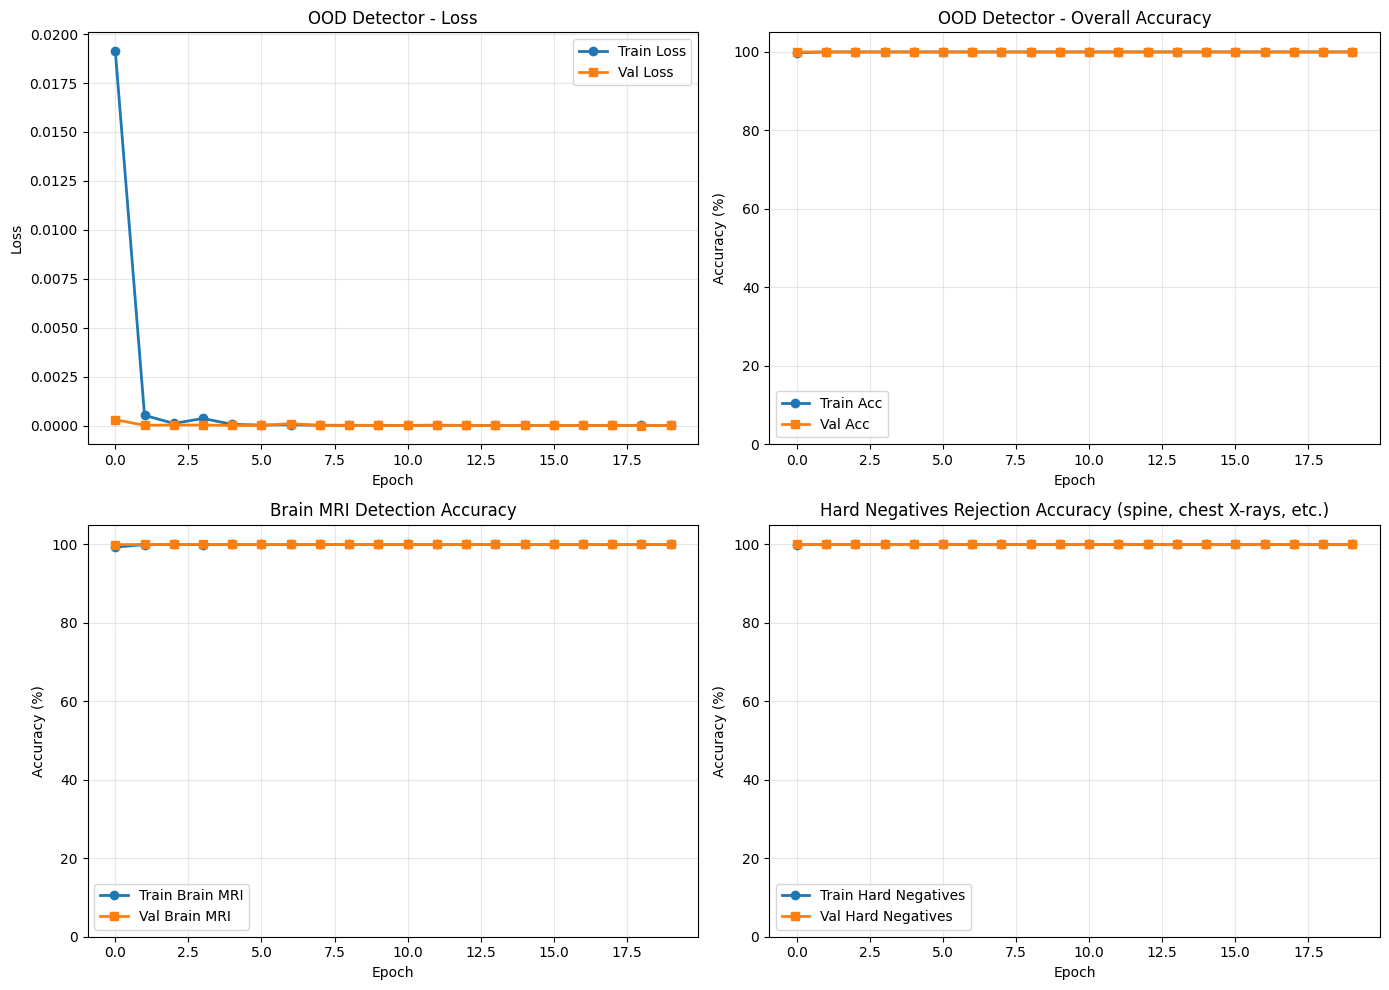


✓ OOD Detector V2 Ready!

Next steps:
1. Run diagnostic to test on spine MRI → should be rejected
2. Copy model to backend: cp models/ood_detector_v2.pth backend/models/ood_detector.pth
3. Redeploy to Hugging Face Spaces
4. Test: spine MRI should now be REJECTED ✓



In [3]:
import torch
import torch.nn as nn
from torchvision import models, transforms
from torch.utils.data import Dataset, DataLoader
from pathlib import Path
from PIL import Image
import numpy as np
from tqdm import tqdm
import matplotlib.pyplot as plt
import time

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")
print(f"GPU: {torch.cuda.get_device_name(0) if torch.cuda.is_available() else 'CPU'}")

# ============================================================================
# 1. OOD DETECTOR MODEL (Same as before)
# ============================================================================

class OODDetector(nn.Module):
    """
    Binary classifier: Is this a brain MRI or not?
    Output: 1 = brain MRI, 0 = not brain MRI
    Uses MobileNetV3-Small (fast, lightweight)
    """
    def __init__(self):
        super().__init__()
        backbone = models.mobilenet_v3_small(
            weights=models.MobileNet_V3_Small_Weights.IMAGENET1K_V1
        )
        in_features = backbone.classifier[0].in_features
        
        # Replace classifier
        backbone.classifier = nn.Sequential(
            nn.Linear(in_features, 64),
            nn.ReLU(inplace=True),
            nn.Dropout(0.3),
            nn.Linear(64, 1)  # Single output for binary classification
        )
        self.backbone = backbone
    
    def forward(self, x):
        return self.backbone(x)

print("✓ OOD Detector model defined")

# ============================================================================
# 2. DATASET WITH HARD NEGATIVES
# ============================================================================

class BrainMRIvsHardNegativesDataset(Dataset):
    """
    Loads:
    - Brain MRI images (label=1, POSITIVE)
    - Hard negative medical images:
      * Spine MRI (different anatomy, similar modality)
      * Chest X-rays (different anatomy, different modality)
      * Bone/extremity X-rays (different anatomy, different modality)
    (label=0, NEGATIVE)
    """
    def __init__(self, mri_dir, hard_negatives_dir, transform=None, max_samples=None):
        self.transform = transform
        self.samples = []
        
        # ========== POSITIVE: Brain MRI ==========
        print("\n" + "="*70)
        print("LOADING POSITIVE SAMPLES (Brain MRI)")
        print("="*70)
        mri_path = Path(mri_dir)
        
        if not mri_path.exists():
            raise FileNotFoundError(f"Brain MRI directory not found: {mri_path}")
        
        mri_count = 0
        for img_path in sorted(mri_path.rglob("*.jpg")) + sorted(mri_path.rglob("*.png")):
            if max_samples and mri_count >= max_samples:
                break
            self.samples.append((str(img_path), 1.0, "brain_mri"))
            mri_count += 1
        
        print(f"✓ Loaded {mri_count} brain MRI images")
        
        # ========== NEGATIVE: Hard Negatives ==========
        print("\n" + "="*70)
        print("LOADING NEGATIVE SAMPLES (Hard Negatives)")
        print("="*70)
        hard_neg_path = Path(hard_negatives_dir)
        
        if not hard_neg_path.exists():
            raise FileNotFoundError(f"Hard negatives directory not found: {hard_neg_path}")
        
        # Count images by type
        hard_neg_count = 0
        spine_count = 0
        chest_count = 0
        bone_count = 0
        
        for img_path in sorted(hard_neg_path.rglob("*.jpg")) + sorted(hard_neg_path.rglob("*.png")):
            if max_samples and hard_neg_count >= max_samples * 3:  # Allow 3x hard negatives
                break
            
            # Categorize by folder
            if "spine" in str(img_path).lower():
                self.samples.append((str(img_path), 0.0, "spine_mri"))
                spine_count += 1
            elif "chest" in str(img_path).lower():
                self.samples.append((str(img_path), 0.0, "chest_xray"))
                chest_count += 1
            elif "bone" in str(img_path).lower() or "xray" in str(img_path).lower():
                self.samples.append((str(img_path), 0.0, "bone_xray"))
                bone_count += 1
            else:
                self.samples.append((str(img_path), 0.0, "other_medical"))
            
            hard_neg_count += 1
        
        print(f"✓ Loaded {hard_neg_count} hard negative images:")
        print(f"  - Spine MRI: {spine_count}")
        print(f"  - Chest X-rays: {chest_count}")
        print(f"  - Bone/other X-rays: {bone_count}")
        
        # ========== SUMMARY ==========
        print("\n" + "="*70)
        print("DATASET SUMMARY")
        print("="*70)
        print(f"Total samples: {len(self.samples)}")
        print(f"  Brain MRI (positive): {mri_count}")
        print(f"  Hard negatives (negative): {hard_neg_count}")
        print(f"  Ratio: 1 brain : {hard_neg_count/mri_count:.1f} hard negatives")
        print(f"  Task difficulty: {'HARD (challenging)' if hard_neg_count/mri_count > 2 else 'MODERATE'}")
        print("="*70 + "\n")
    
    def __len__(self):
        return len(self.samples)
    
    def __getitem__(self, idx):
        img_path, label, category = self.samples[idx]
        try:
            image = Image.open(img_path).convert("RGB")
            if self.transform:
                image = self.transform(image)
            return image, torch.tensor(label, dtype=torch.float32), category
        except Exception as e:
            print(f"Error loading {img_path}: {e}")
            # Return dummy data on error
            return torch.randn(3, 224, 224), torch.tensor(label, dtype=torch.float32), category

print("✓ Dataset class defined")

# ============================================================================
# 3. TRAINING FUNCTION
# ============================================================================

def train_ood_detector_with_hard_negatives(
    mri_dir="../data/raw",
    hard_negatives_dir="../data/hard_negatives",
    save_path="../models/ood_detector_v2.pth",
    epochs=20,
    batch_size=32,
    learning_rate=1e-4
):
    """
    Train binary OOD detector with hard negatives.
    This version should properly reject spine MRI, chest X-rays, etc.
    """
    
    # Transform
    transform = transforms.Compose([
        transforms.Resize((224, 224)),
        transforms.RandomHorizontalFlip(p=0.3),
        transforms.RandomRotation(degrees=10),
        transforms.ColorJitter(brightness=0.1, contrast=0.1),
        transforms.ToTensor(),
        transforms.Normalize(
            mean=[0.485, 0.456, 0.406],
            std=[0.229, 0.224, 0.225]
        )
    ])
    
    val_transform = transforms.Compose([
        transforms.Resize((224, 224)),
        transforms.ToTensor(),
        transforms.Normalize(
            mean=[0.485, 0.456, 0.406],
            std=[0.229, 0.224, 0.225]
        )
    ])
    
    # Dataset
    print("\n" + "="*70)
    print("PREPARING DATASET")
    print("="*70)
    dataset = BrainMRIvsHardNegativesDataset(mri_dir, hard_negatives_dir, transform)
    
    # Train/Val split: 80/20
    n = len(dataset)
    n_train = int(0.8 * n)
    n_val = n - n_train
    
    train_ds, val_ds = torch.utils.data.random_split(
        dataset, [n_train, n_val],
        generator=torch.Generator().manual_seed(42)
    )
    
    train_loader = DataLoader(
        train_ds, 
        batch_size=batch_size, 
        shuffle=True, 
        num_workers=0,
        pin_memory=True
    )
    val_loader = DataLoader(
        val_ds, 
        batch_size=batch_size, 
        shuffle=False, 
        num_workers=0,
        pin_memory=True
    )
    
    print(f"\nTrain samples: {n_train}")
    print(f"Val samples: {n_val}")
    
    # Model
    print("\n" + "="*70)
    print("INITIALIZING MODEL")
    print("="*70)
    model = OODDetector().to(device)
    
    total_params = sum(p.numel() for p in model.parameters())
    trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
    print(f"Total parameters: {total_params:,}")
    print(f"Trainable parameters: {trainable_params:,}")
    
    # Optimizer & loss
    optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate)
    criterion = nn.BCEWithLogitsLoss()
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
        optimizer, mode='max', factor=0.5, patience=2, verbose=True
    )
    
    # Training loop
    print("\n" + "="*70)
    print("TRAINING OOD DETECTOR WITH HARD NEGATIVES")
    print("="*70)
    
    history = {
        'train_loss': [],
        'val_loss': [],
        'train_acc': [],
        'val_acc': [],
        'train_brain_acc': [],
        'train_neg_acc': [],
        'val_brain_acc': [],
        'val_neg_acc': []
    }
    
    best_val_acc = 0.0
    start_time = time.time()
    
    for epoch in range(epochs):
        # ===== TRAIN =====
        model.train()
        train_loss = 0.0
        train_correct = 0
        train_total = 0
        train_brain_correct = 0
        train_brain_total = 0
        train_neg_correct = 0
        train_neg_total = 0
        
        pbar = tqdm(train_loader, desc=f"Epoch {epoch+1}/{epochs} [TRAIN]", leave=False)
        for images, labels, categories in pbar:
            images = images.to(device)
            labels = labels.to(device).unsqueeze(1)
            
            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()
            
            train_loss += loss.item()
            predicted = (torch.sigmoid(outputs) > 0.5).float().squeeze(1)
            
            correct = (predicted == labels.squeeze(1))
            train_correct += correct.sum().item()
            train_total += labels.size(0)
            
            # Track per-class accuracy
            brain_mask = (labels.squeeze(1) == 1)
            neg_mask = (labels.squeeze(1) == 0)
            
            if brain_mask.sum() > 0:
                train_brain_correct += correct[brain_mask].sum().item()
                train_brain_total += brain_mask.sum().item()
            
            if neg_mask.sum() > 0:
                train_neg_correct += correct[neg_mask].sum().item()
                train_neg_total += neg_mask.sum().item()
            
            pbar.set_postfix({'loss': f'{loss.item():.4f}'})
        
        train_loss /= len(train_loader)
        train_acc = 100 * train_correct / train_total
        train_brain_acc = 100 * train_brain_correct / train_brain_total if train_brain_total > 0 else 0
        train_neg_acc = 100 * train_neg_correct / train_neg_total if train_neg_total > 0 else 0
        
        history['train_loss'].append(train_loss)
        history['train_acc'].append(train_acc)
        history['train_brain_acc'].append(train_brain_acc)
        history['train_neg_acc'].append(train_neg_acc)
        
        # ===== VALIDATE =====
        model.eval()
        val_loss = 0.0
        val_correct = 0
        val_total = 0
        val_brain_correct = 0
        val_brain_total = 0
        val_neg_correct = 0
        val_neg_total = 0
        
        with torch.no_grad():
            pbar = tqdm(val_loader, desc=f"Epoch {epoch+1}/{epochs} [VAL]", leave=False)
            for images, labels, categories in pbar:
                images = images.to(device)
                labels = labels.to(device).unsqueeze(1)
                
                outputs = model(images)
                loss = criterion(outputs, labels)
                
                val_loss += loss.item()
                predicted = (torch.sigmoid(outputs) > 0.5).float().squeeze(1)
                
                correct = (predicted == labels.squeeze(1))
                val_correct += correct.sum().item()
                val_total += labels.size(0)
                
                # Track per-class accuracy
                brain_mask = (labels.squeeze(1) == 1)
                neg_mask = (labels.squeeze(1) == 0)
                
                if brain_mask.sum() > 0:
                    val_brain_correct += correct[brain_mask].sum().item()
                    val_brain_total += brain_mask.sum().item()
                
                if neg_mask.sum() > 0:
                    val_neg_correct += correct[neg_mask].sum().item()
                    val_neg_total += neg_mask.sum().item()
                
                pbar.set_postfix({'loss': f'{loss.item():.4f}'})
        
        val_loss /= len(val_loader)
        val_acc = 100 * val_correct / val_total
        val_brain_acc = 100 * val_brain_correct / val_brain_total if val_brain_total > 0 else 0
        val_neg_acc = 100 * val_neg_correct / val_neg_total if val_neg_total > 0 else 0
        
        history['val_loss'].append(val_loss)
        history['val_acc'].append(val_acc)
        history['val_brain_acc'].append(val_brain_acc)
        history['val_neg_acc'].append(val_neg_acc)
        
        # Print results
        print(f"\nEpoch [{epoch+1}/{epochs}]")
        print(f"  Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.2f}%")
        print(f"    - Brain MRI accuracy: {train_brain_acc:.2f}%")
        print(f"    - Hard negatives accuracy: {train_neg_acc:.2f}%")
        print(f"  Val Loss: {val_loss:.4f} | Val Acc: {val_acc:.2f}%")
        print(f"    - Brain MRI accuracy: {val_brain_acc:.2f}%")
        print(f"    - Hard negatives accuracy: {val_neg_acc:.2f}%")
        
        # Save best model
        if val_acc > best_val_acc:
            best_val_acc = val_acc
            torch.save({
                'model_state_dict': model.state_dict(),
                'epoch': epoch,
                'best_val_acc': best_val_acc,
                'history': history
            }, save_path)
            print(f"  ✓ Best model saved (acc: {val_acc:.2f}%)")
        
        scheduler.step(val_acc)
    
    elapsed = time.time() - start_time
    print("\n" + "="*70)
    print("TRAINING COMPLETE")
    print("="*70)
    print(f"Total time: {elapsed/60:.1f} minutes")
    print(f"Best validation accuracy: {best_val_acc:.2f}%")
    print(f"Model saved to: {save_path}")
    print("="*70 + "\n")
    
    return history, model


# ============================================================================
# 4. VISUALIZATION
# ============================================================================

def plot_training_history(history):
    """Plot training curves with per-class breakdown."""
    fig, axes = plt.subplots(2, 2, figsize=(14, 10))
    
    # Loss
    axes[0, 0].plot(history['train_loss'], label='Train Loss', marker='o', linewidth=2)
    axes[0, 0].plot(history['val_loss'], label='Val Loss', marker='s', linewidth=2)
    axes[0, 0].set_xlabel('Epoch')
    axes[0, 0].set_ylabel('Loss')
    axes[0, 0].set_title('OOD Detector - Loss')
    axes[0, 0].legend()
    axes[0, 0].grid(True, alpha=0.3)
    
    # Overall Accuracy
    axes[0, 1].plot(history['train_acc'], label='Train Acc', marker='o', linewidth=2)
    axes[0, 1].plot(history['val_acc'], label='Val Acc', marker='s', linewidth=2)
    axes[0, 1].set_xlabel('Epoch')
    axes[0, 1].set_ylabel('Accuracy (%)')
    axes[0, 1].set_title('OOD Detector - Overall Accuracy')
    axes[0, 1].set_ylim([0, 105])
    axes[0, 1].legend()
    axes[0, 1].grid(True, alpha=0.3)
    
    # Brain MRI Accuracy
    axes[1, 0].plot(history['train_brain_acc'], label='Train Brain MRI', marker='o', linewidth=2)
    axes[1, 0].plot(history['val_brain_acc'], label='Val Brain MRI', marker='s', linewidth=2)
    axes[1, 0].set_xlabel('Epoch')
    axes[1, 0].set_ylabel('Accuracy (%)')
    axes[1, 0].set_title('Brain MRI Detection Accuracy')
    axes[1, 0].set_ylim([0, 105])
    axes[1, 0].legend()
    axes[1, 0].grid(True, alpha=0.3)
    
    # Hard Negatives Accuracy (ability to reject non-brain-MRI)
    axes[1, 1].plot(history['train_neg_acc'], label='Train Hard Negatives', marker='o', linewidth=2)
    axes[1, 1].plot(history['val_neg_acc'], label='Val Hard Negatives', marker='s', linewidth=2)
    axes[1, 1].set_xlabel('Epoch')
    axes[1, 1].set_ylabel('Accuracy (%)')
    axes[1, 1].set_title('Hard Negatives Rejection Accuracy (spine, chest X-rays, etc.)')
    axes[1, 1].set_ylim([0, 105])
    axes[1, 1].legend()
    axes[1, 1].grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.savefig('../results/ood_detector_v2_training.png', dpi=150, bbox_inches='tight')
    print("\n✓ Training curves saved to: ../results/ood_detector_v2_training.png")
    plt.show()


# ============================================================================
# 5. RUN TRAINING
# ============================================================================

print("\n")
print("█" * 70)
print("OOD DETECTOR V2 TRAINING WITH HARD NEGATIVES")
print("(Brain MRI vs Spine MRI, Chest X-rays, Bone X-rays)")
print("█" * 70)
print("\n")

history, model = train_ood_detector_with_hard_negatives(
    mri_dir="../data/raw",
    hard_negatives_dir="../data/hard_negatives",
    save_path="../models/ood_detector_v2.pth",
    epochs=20,
    batch_size=32,
    learning_rate=1e-4
)

plot_training_history(history)

print("\n" + "="*70)
print("✓ OOD Detector V2 Ready!")
print("="*70)
print("\nNext steps:")
print("1. Run diagnostic to test on spine MRI → should be rejected")
print("2. Copy model to backend: cp models/ood_detector_v2.pth backend/models/ood_detector.pth")
print("3. Redeploy to Hugging Face Spaces")
print("4. Test: spine MRI should now be REJECTED ✓")
print("="*70 + "\n")